In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Crop_recommendation.csv")

# Display first 5 rows
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 975.5 kB/s  0:00:10 eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 1.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Check dataset size
print("Dataset shape:", df.shape)

# Check column names and data types
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())        

# Count samples for each crop
print("\nCrop classes:")
print(df["label"].value_counts())

Dataset shape: (2200, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Crop classes:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mang

In [6]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Check missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)

# Remove duplicates if any exist
df = df.drop_duplicates()

# Confirm final dataset shape
print("\nDataset shape after cleaning:", df.shape)  

Duplicate rows: 0

Missing values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Dataset shape after cleaning: (2200, 8)


In [7]:
# Select the seven input features for the ML model
features = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

# X = inputs given to the model
X = df[features]

# y = crop label that the model must predict
y = df["label"]

# Check the result
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nInput features:")
print(X.head())

print("\nTarget crop labels:")
print(y.head())

X shape: (2200, 7)
y shape: (2200,)

Input features:
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340

Target crop labels:
0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: str


In [8]:
from sklearn.model_selection import train_test_split

# 80% data for training, 20% data for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training input shape:", X_train.shape)
print("Testing input shape:", X_test.shape)

print("\nTraining label shape:", y_train.shape)
print("Testing label shape:", y_test.shape)

Training input shape: (1760, 7)
Testing input shape: (440, 7)

Training label shape: (1760,)
Testing label shape: (440,)


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model using training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
from sklearn.metrics import accuracy_score, classification_report

# Predict crop labels for unseen testing data
y_pred = rf_model.predict(X_test)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Show detailed performance for each crop
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 99.32%

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00

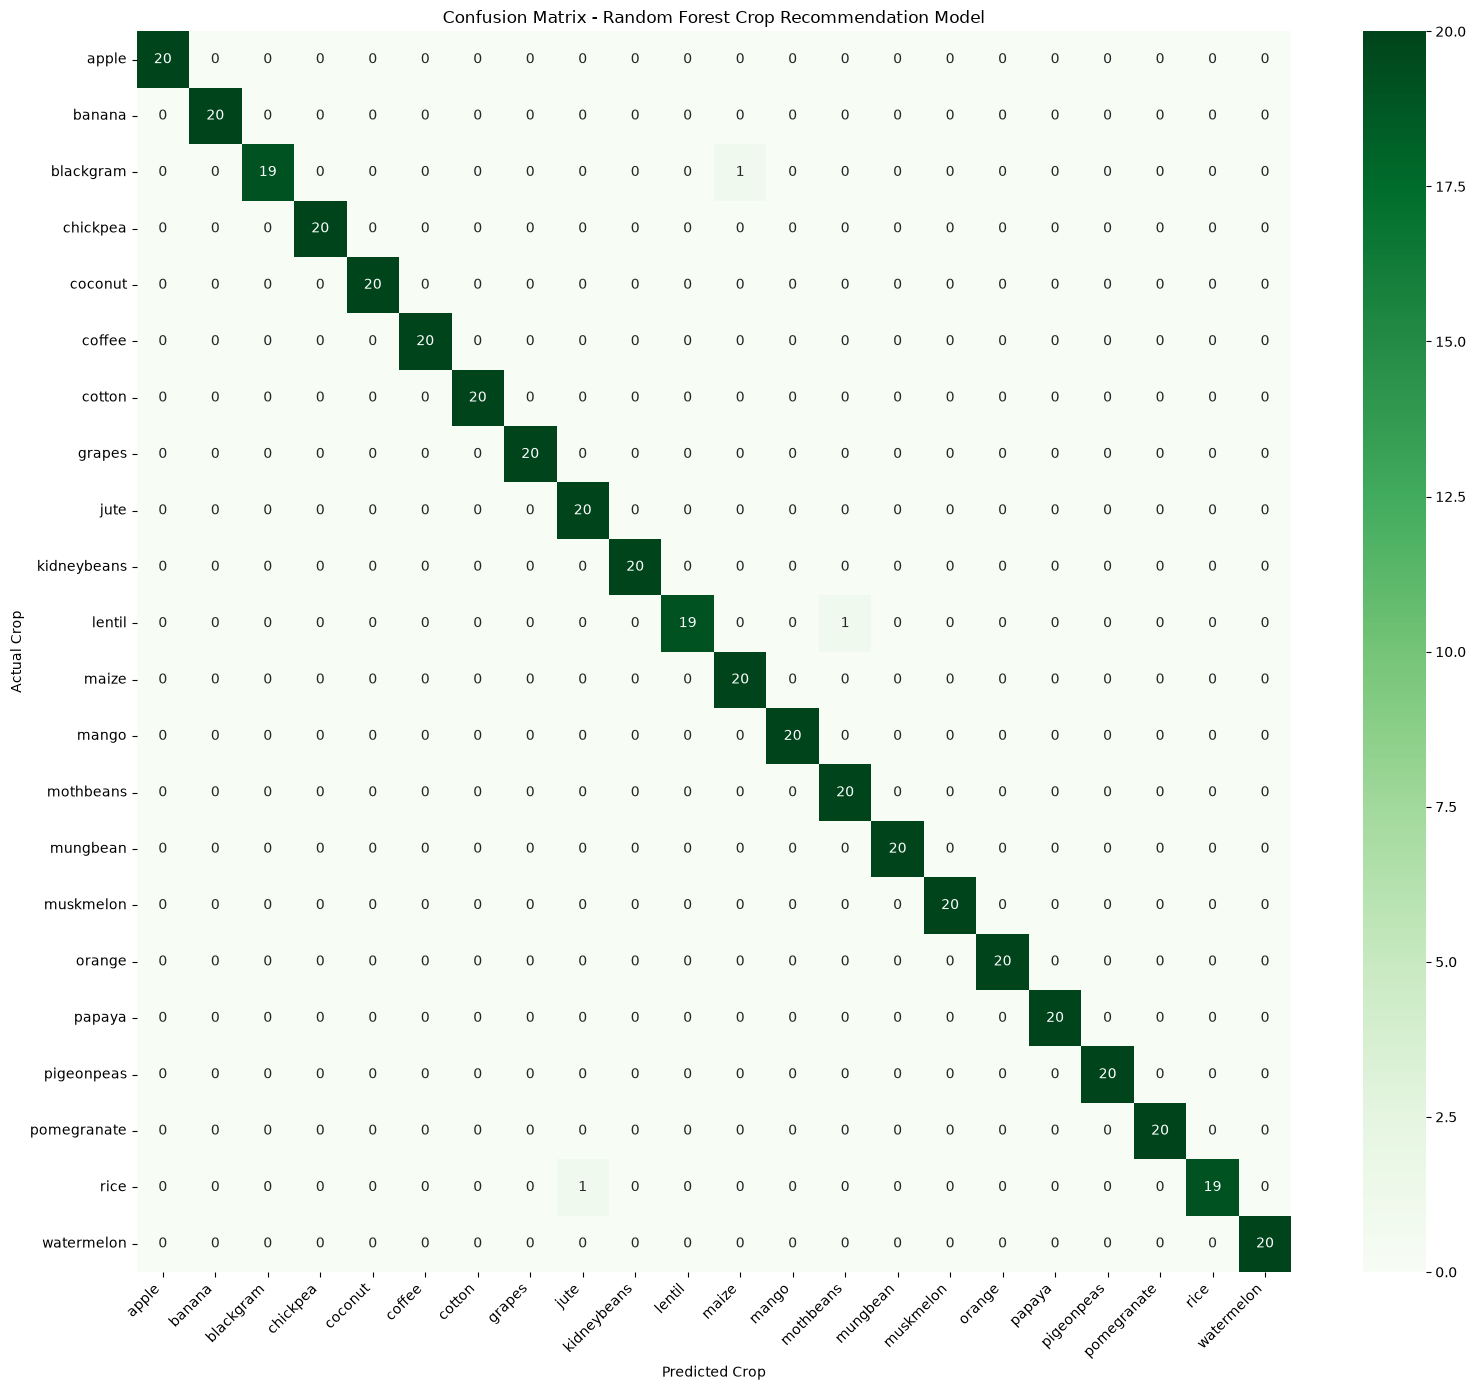

In [11]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

# Display it
plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title("Confusion Matrix - Random Forest Crop Recommendation Model")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

       Feature  Importance
6     rainfall    0.216295
4     humidity    0.216189
2            K    0.178812
1            P    0.149694
0            N    0.105393
3  temperature    0.077112
5           ph    0.056505


/var/folders/v4/2ltbxy0d05ng5hsfccngr9qc0000gn/T/ipykernel_10830/1059900382.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


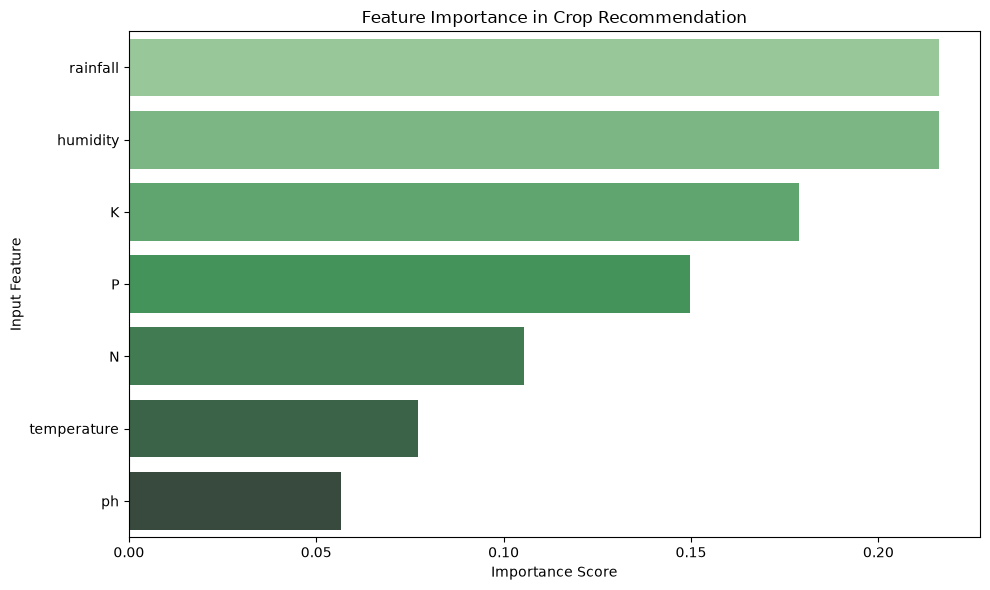

In [12]:
# Create a DataFrame of feature importance values
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display values
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="Greens_d"
)

plt.title("Feature Importance in Crop Recommendation")
plt.xlabel("Importance Score")
plt.ylabel("Input Feature")
plt.tight_layout()
plt.show()                                          

In [13]:
import os
import joblib

# Create the models folder if it does not already exist
os.makedirs("../models", exist_ok=True)

# Save the trained Random Forest model
joblib.dump(rf_model, "../models/crop_recommendator.pkl")

print("Model saved successfully!")
print("Location: ../models/crop_recommendator.pkl") 

Model saved successfully!
Location: ../models/crop_recommendator.pkl


In [14]:
import joblib

# Load saved model
loaded_model = joblib.load("../models/crop_recommendator.pkl")

# Test input: N, P, K, temperature, humidity, pH, rainfall
sample_input = [[
    90,
    42,
    43,
    20.88,
    82.00,
    6.50,
    202.94
]]

# Predict crop
prediction = loaded_model.predict(sample_input)[0]

# Get confidence
confidence = loaded_model.predict_proba(sample_input).max()

print("Recommended crop:", prediction)
print(f"Model confidence: {confidence * 100:.2f}%") 

Recommended crop: rice
Model confidence: 95.00%


/Users/stutisamanta/Desktop/Crop/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/stutisamanta/Desktop/Crop/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
import pandas as pd
import joblib

# Load the saved model
loaded_model = joblib.load("../models/crop_recommendator.pkl")

# Create one test input with named columns
input_data = pd.DataFrame([[
    90,      # N
    42,      # P
    43,      # K
    20.88,   # temperature
    82.00,   # humidity
    6.50,    # ph
    202.94   # rainfall
]], columns=[
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
])

# Predict crop and confidence
prediction = loaded_model.predict(input_data)[0]
confidence = loaded_model.predict_proba(input_data).max()

print("Recommended crop:", prediction)
print(f"Model confidence: {confidence * 100:.2f}%")

Recommended crop: rice
Model confidence: 95.00%


In [16]:
# Predict crops for the first 10 unseen test records
test_predictions = loaded_model.predict(X_test.head(10))

# Create a comparison table
comparison = X_test.head(10).copy()

comparison["Actual Crop"] = y_test.head(10).values
comparison["Predicted Crop"] = test_predictions
comparison["Correct Prediction"] = (
    comparison["Actual Crop"] == comparison["Predicted Crop"]
)

comparison

,N,P,K,temperature,humidity,ph,rainfall,Actual Crop,Predicted Crop,Correct Prediction
1609,13,23,6,23.961476,90.264080,7.365338,102.695870,orange,orange,True
1072,98,79,50,25.341198,84.473213,6.435917,91.064934,banana,banana,True
1912,140,38,15,24.147295,75.882986,6.021440,69.915635,cotton,cotton,True
100,71,54,16,22.613600,63.690706,5.749914,87.759539,maize,maize,True
1645,40,22,6,24.536101,91.909972,6.488221,115.978799,orange,orange,True
221,25,68,77,20.093406,15.112796,7.701446,85.749049,chickpea,chickpea,True
28,60,49,44,20.775761,84.497744,6.244841,240.081065,rice,rice,True
701,25,62,21,26.734340,68.139997,7.040056,67.150964,blackgram,blackgram,True
1097,110,71,54,28.672089,82.207936,5.725419,94.379875,banana,banana,True
1638,10,5,5,21.213070,91.353492,7.817846,112.983436,orange,orange,True


In [17]:
# Use the first unseen test row
one_test_input = X_test.iloc[[0]]

# Get probabilities for every crop
probabilities = loaded_model.predict_proba(one_test_input)[0]

# Create crop-probability table
top_3 = pd.DataFrame({
    "Crop": loaded_model.classes_,
    "Confidence": probabilities * 100
})

# Show the three most likely crops
top_3 = top_3.sort_values(
    by="Confidence",
    ascending=False
).head(3)

top_3["Confidence"] = top_3["Confidence"].round(2).astype(str) + "%"

print("Actual crop:", y_test.iloc[0])
top_3

Actual crop: orange


,Crop,Confidence
16,orange,98.0%
19,pomegranate,1.5%
12,mango,0.5%


In [18]:
# Use the first unseen test row
one_test_input = X_test.iloc[[0]]

# Get probability for every crop
probabilities = loaded_model.predict_proba(one_test_input)[0]

# Create crop-confidence table
top_3 = pd.DataFrame({
    "Crop": loaded_model.classes_,
    "Confidence": probabilities * 100
})

# Sort and keep only the top 3 crops
top_3 = top_3.sort_values(
    by="Confidence",
    ascending=False
).head(3)

# Make the table index clean
top_3 = top_3.reset_index(drop=True)

# Format confidence values
top_3["Confidence"] = top_3["Confidence"].round(2).astype(str) + "%"

print("Actual crop:", y_test.iloc[0])
top_3

Actual crop: orange


,Crop,Confidence
0,orange,98.0%
1,pomegranate,1.5%
2,mango,0.5%


In [19]:
import os
import joblib
from pathlib import Path

# Use the existing trained model from this notebook
# Do NOT retrain; just reuse rf_model that already exists in memory.
try:
    rf_model
except NameError:
    raise NameError(
        "Model variable 'rf_model' is not defined. "
        "Run all previous cells in this notebook first."
    )

# Create a 'models' folder next to this notebook
notebook_dir = Path.cwd()
models_dir = notebook_dir / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "crop_recommendator.pkl"

# Save the existing model to disk
joblib.dump(rf_model, model_path)

print("Model saved successfully!")
print("Full path:", model_path.resolve())
print("File exists:", model_path.exists())

Model saved successfully!
Full path: /Users/stutisamanta/Desktop/Crop/AI-powered-Crop-Advisory-System/models/models/crop_recommendator.pkl
File exists: True


In [22]:
from pathlib import Path

notebook_dir = Path.cwd()
print("Notebook directory:", notebook_dir)

candidates = [
    notebook_dir / "models" / "crop_recommendator.pkl",
    notebook_dir.parent / "models" / "crop_recommendator.pkl",
]

for p in candidates:
    print(p.resolve(), "=> exists:", p.exists())

Notebook directory: /Users/stutisamanta/Desktop/Crop/AI-powered-Crop-Advisory-System/models
/Users/stutisamanta/Desktop/Crop/AI-powered-Crop-Advisory-System/models/models/crop_recommendator.pkl => exists: True
/Users/stutisamanta/Desktop/Crop/AI-powered-Crop-Advisory-System/models/crop_recommendator.pkl => exists: True
